In [1]:
import numpy as np
import pandas as pd
import ast
from sqlite3 import Time


# 1. Prevent Pandas from wrapping columns into multiple lines
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)        # Set a wide display threshold
pd.set_option('display.max_rows', None)     # Show all rows

# Load a 50,000-row sample first (full file has ~1M rows)
#df = pd.read_csv('SGJobData.csv', nrows=50000)
df = pd.read_csv('../SGJobData.csv')

print(df.head())
print(df.shape)   # (rows, columns)

# 1. Structural Description: View column names, non-null counts, and data types
print("--- STRUCTURAL INFO ---")
df.info()

# 2. Statistical Description (Numeric columns): View count, mean, min, max, and percentiles
print("\n--- NUMERIC COLUMNS DESCRIBE ---")
print(df.describe())

# 3. Text/Categorical Description (String columns): View count, unique values, top item, and frequency
print("\n--- TEXT/CATEGORICAL COLUMNS DESCRIBE ---")
print(df.describe(include=['object']))


#unique values and their exact counts for each column
for column in df.columns:
    print(f"=== Unique Values for Column: {column} ===")
    print(df[column].value_counts().head(10))  # Show top 10 unique values
    print("\n" + "-"*40 + "\n")  # Visual separator


'''
#unique values and their exact counts for each column
for column in df.columns:
    print(f"=== Unique Values for Column: {column} ===")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")  # Visual separator
'''

# Count how many exact duplicate rows exist before dropping
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Find and print the missing value counts for each column
print("=== Missing Values ===")
print(df.isnull().sum())


                                          categories employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies  occupationId    positionLevels                postedCompany_name  salary_maximum  salary_minimum salary_type  status_id status_jobStatus                                              title  average_salary
0  [{"id":13,"category":"Environment / Health"},{...       Permanent          2023-05-08                      False   MCF-2023-0252866              2023-04-08                   2023-03-30                     2                                   5                         151                       0                  1           NaN         Executive               WORKSTONE PTE. LTD.            2800            2000     Monthly          0           Closed  Food Technologist - Cl

In [2]:
# Data cleaning
'''
clean is based on "report/data_dictionary.md" 
'''    
#-----remove duplicates rows, drop unnecessary columns, drop single row with missing values

# Drop duplicates, keep='first' ensures you keep the first occurrence and delete the rest
df = df.drop_duplicates(keep='first')

# Drop columns that are not useful for analysis
columns_to_drop = ['occupationId', 'status_id', 'status_jobStatus', 'salary_type']
df = df.drop(columns=columns_to_drop, axis=1)

# Get row indices where any column has a missing value
missing_rows = df[df.isnull().any(axis=1)].index.tolist()
print("Rows with missing values:")
print(missing_rows)

# Drop the row with missing values (row 197478)
df = df.dropna()

'''
# This part is TBD
# Filter dataframe to keep rows where both salary_minimum and salary_maximum are within specified ranges
sal_min=500
sal_max=250000
df = df.query(f"{sal_min} <= salary_minimum <= {sal_max} and {sal_min} <= salary_maximum <= {sal_max}")
'''

# Convert metadata_expiryDate, metadata_newPostingDate, metadata_originalPostingDate to datetime format
date_cols = [
    "metadata_expiryDate",
    "metadata_newPostingDate",
    "metadata_originalPostingDate",
]
df[date_cols] = df[date_cols].apply(pd.to_datetime)


#-----New Features in Database (15 columns)

# Salary-Related Features
df['salary_median'] = ((df['salary_minimum'] + df['salary_maximum']) / 2).astype(int)
df['salary_range_width'] = (df['salary_maximum'] - df['salary_minimum']).astype(int)
conditions = [
    (df['salary_median'] < 3000),
    (df['salary_median'] >= 3000) & (df['salary_median'] < 6000),
    (df['salary_median'] >= 6000) & (df['salary_median'] < 10000),
    (df['salary_median'] >= 10000) & (df['salary_median'] <= 20000),
    (df['salary_median'] > 20000)
]
categories = ['Entry', 'Mid', 'Senior', 'Lead', 'Executive']
df['salary_band'] = np.select(conditions, categories, default='Unknown')

#Competition & Demand Features
df['applications_per_vacancy'] = df['metadata_totalNumberJobApplication'] / df['numberOfVacancies']
repost_median = df['metadata_repostCount'].median()
apps_per_vac_median = df['applications_per_vacancy'].median()
df['is_hard_to_fill'] = (
    (df['metadata_repostCount'] > repost_median) & 
    (df['applications_per_vacancy'] < apps_per_vac_median)
)
df['is_selective_hire'] = (
    (df['metadata_repostCount'] < repost_median) & 
    (df['applications_per_vacancy'] > apps_per_vac_median)
)

#Industry Features
parsed_series = df['categories'].apply(ast.literal_eval)
df['industry_list'] = [",".join([item['category'] for item in row]) for row in parsed_series]
df['industry_primary'] = [row[0]['category'] for row in parsed_series]

df = df.drop(columns='categories', axis=1)

#add one-hot encoding for industry_list
#df_encoded = df['industry_list'].str.get_dummies(sep=',')
#df = df.join(df_encoded)

#Time-Based Features
df['posting_year'] = df['metadata_originalPostingDate'].dt.year
df['posting_month'] = df['metadata_originalPostingDate'].dt.month
df['posting_quarter'] = df['metadata_originalPostingDate'].dt.quarter
df['posting_weekday'] = df['metadata_originalPostingDate'].dt.weekday
df['days_to_expiry'] = (df['metadata_expiryDate'] - df['metadata_originalPostingDate']).dt.days

#Additional Features
df['is_agency_post'] = df['metadata_isPostedOnBehalf'].astype(bool)
df['posting_month_year'] = df['metadata_originalPostingDate'].dt.strftime('%Y-%m')

print("=== Data Cleaning Complete ===")


Rows with missing values:
[197478]
=== Data Cleaning Complete ===


In [3]:
# re-check the db after cleaning

print(df.head())
print(df.shape)   # (rows, columns)

# 1. Structural Description: View column names, non-null counts, and data types
print("--- STRUCTURAL INFO ---")
df.info()

# 2. Statistical Description (Numeric columns): View count, mean, min, max, and percentiles
print("\n--- NUMERIC COLUMNS DESCRIBE ---")
print(df.describe())

# 3. Text/Categorical Description (String columns): View count, unique values, top item, and frequency
print("\n--- TEXT/CATEGORICAL COLUMNS DESCRIBE ---")
print(df.describe(include=['object']))

'''
#unique values and their exact counts for each column
for column in df.columns:
    print(f"=== Unique Values for Column: {column} ===")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")  # Visual separator
'''

# Count how many exact duplicate rows exist before dropping
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Find and print the missing value counts for each column
print("=== Missing Values ===")
print(df.isnull().sum())

  employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies    positionLevels                postedCompany_name  salary_maximum  salary_minimum                                              title  average_salary  salary_median  salary_range_width salary_band  applications_per_vacancy  is_hard_to_fill  is_selective_hire                                      industry_list        industry_primary  posting_year  posting_month  posting_quarter  posting_weekday  days_to_expiry  is_agency_post posting_month_year
0       Permanent          2023-05-08                      False   MCF-2023-0252866              2023-04-08                   2023-03-30                     2                                   5                         151                       0                  1         Executive  

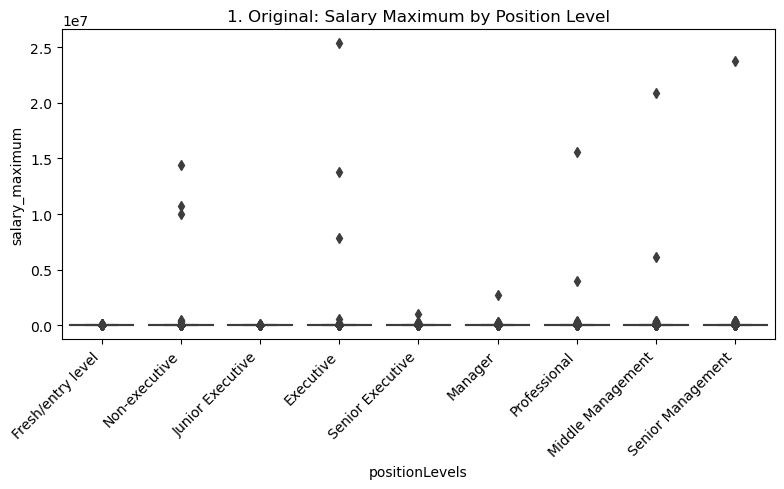

--- 2. TOP 12 SALARY MAXIMUM RECORDS ---
               employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf                 metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies     positionLevels                                 postedCompany_name  salary_maximum  salary_minimum                                              title  average_salary  salary_median  salary_range_width salary_band  applications_per_vacancy  is_hard_to_fill  is_selective_hire                                      industry_list                  industry_primary  posting_year  posting_month  posting_quarter  posting_weekday  days_to_expiry  is_agency_post posting_month_year
359527               Full Time          2023-09-27                      False                   MCF-2023-0659775              2023-08-28                   2023-08-28                     0

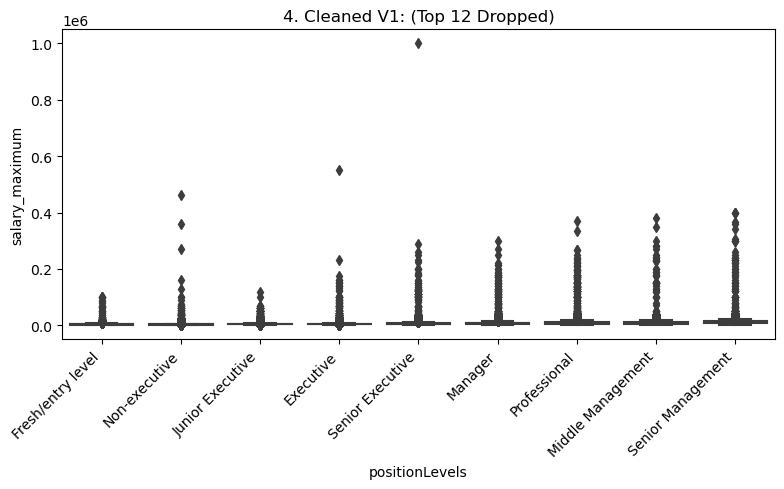


--- 5a. OVERALL TOP 3 SALARY MAXIMUM RECORDS (V1) ---
       employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies    positionLevels             postedCompany_name  salary_maximum  salary_minimum                                       title  average_salary  salary_median  salary_range_width salary_band  applications_per_vacancy  is_hard_to_fill  is_selective_hire                           industry_list     industry_primary  posting_year  posting_month  posting_quarter  posting_weekday  days_to_expiry  is_agency_post posting_month_year
575992       Temporary          2023-12-20                      False   MCF-2023-0897073              2023-11-20                   2023-11-20                     0                                   0                           1                      

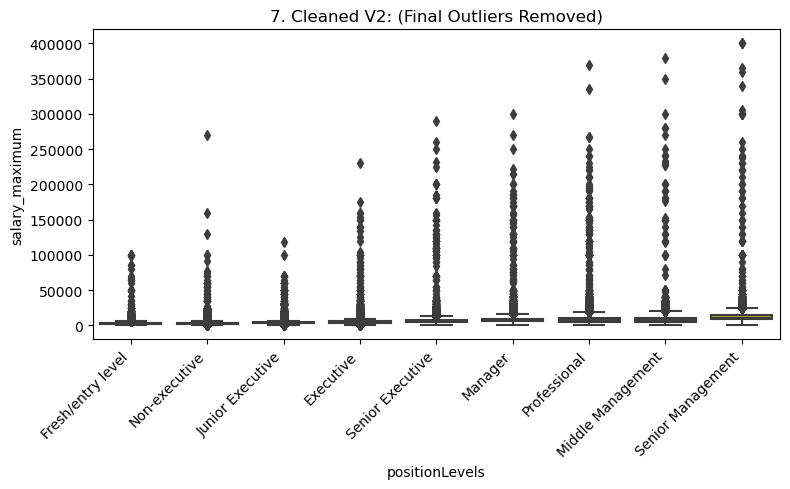


--- 8. TOP 1 SALARY MAXIMUM OF EACH POSITION LEVEL (FINAL) ---
       employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies     positionLevels                                 postedCompany_name  salary_maximum  salary_minimum                                        title  average_salary  salary_median  salary_range_width salary_band  applications_per_vacancy  is_hard_to_fill  is_selective_hire                                      industry_list        industry_primary  posting_year  posting_month  posting_quarter  posting_weekday  days_to_expiry  is_agency_post posting_month_year
581851       Full Time          2023-12-06                      False   MCF-2023-0909376              2023-11-22                   2023-11-22                     0                                   1     

(1044581, 32)

In [4]:
# analysis the high side of the salary_maximum by positionLevels. clean the outliers if any

import matplotlib.pyplot as plt
import seaborn as sns

# ─── CONFIGURATION PARAMETERS ─────────────────────────
top_to_drop_step1 = 12
# ──────────────────────────────────────────────────────

# ==========================================
# STEP 1, 2 & 3: Original Data Analysis
# ==========================================
# 1. Plot original box plot (sorted by median)
order_1 = (
    df.groupby("positionLevels")["salary_maximum"]
    .median()
    .sort_values()
    .index
)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="positionLevels", y="salary_maximum", order=order_1)
plt.title("1. Original: Salary Maximum by Position Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. List records of top 12 salary_maximum
print("--- 2. TOP 12 SALARY MAXIMUM RECORDS ---")
top_12_records = df.nlargest(top_to_drop_step1, "salary_maximum")
print(top_12_records)

# 3. Drop these 12 records
df_cleaned_v1 = df.drop(index=top_12_records.index)


# ==========================================
# STEP 4 & 5: First Cleanup Analysis
# ==========================================
# 4. Redraw the box plot (sorted by new medians)
order_2 = (
    df_cleaned_v1.groupby("positionLevels")["salary_maximum"]
    .median()
    .sort_values()
    .index
)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_cleaned_v1, x="positionLevels", y="salary_maximum", order=order_2
)
plt.title(f"4. Cleaned V1: (Top {top_to_drop_step1} Dropped)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5a. List records of overall top 3 salary_maximum in df_cleaned_v1
print("\n--- 5a. OVERALL TOP 3 SALARY MAXIMUM RECORDS (V1) ---")
top_3_overall = df_cleaned_v1.nlargest(3, "salary_maximum")
print(top_3_overall)

# 5b. List records of top 3 salary_maximum in 'Non-executive' (V1)
print("\n--- 5b. TOP 3 NON-EXECUTIVE SALARY MAXIMUM RECORDS (V1) ---")
non_exec_mask = df_cleaned_v1["positionLevels"] == "Non-executive"
top_3_non_exec = df_cleaned_v1[non_exec_mask].nlargest(3, "salary_maximum")
print(top_3_non_exec)


# ==========================================
# STEP 6: Targeted Dropping (Top 3 Overall + Top 2 Non-Exec)
# ==========================================
# 6. Drop the overall top 3 and the top 2 from the Non-executive group
top_2_non_exec_indices = top_3_non_exec.head(2).index
indices_to_drop_v2 = top_3_overall.index.union(top_2_non_exec_indices)
df_cleaned_v2 = df_cleaned_v1.drop(index=indices_to_drop_v2)


# ==========================================
# STEP 7 & 8: Final Cleanup & Group Summary
# ==========================================
# 7. Redraw the final box plot (sorted by final medians)
order_3 = (
    df_cleaned_v2.groupby("positionLevels")["salary_maximum"]
    .median()
    .sort_values()
    .index
)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_cleaned_v2, x="positionLevels", y="salary_maximum", order=order_3
)
plt.title("7. Cleaned V2: (Final Outliers Removed)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 8. List top 1 salary_maximum of each positionLevels
print("\n--- 8. TOP 1 SALARY MAXIMUM OF EACH POSITION LEVEL (FINAL) ---")
top_1_per_level = df_cleaned_v2.loc[
    df_cleaned_v2.groupby("positionLevels")["salary_maximum"].idxmax()
]
print(top_1_per_level)

df_cleaned_v2.shape






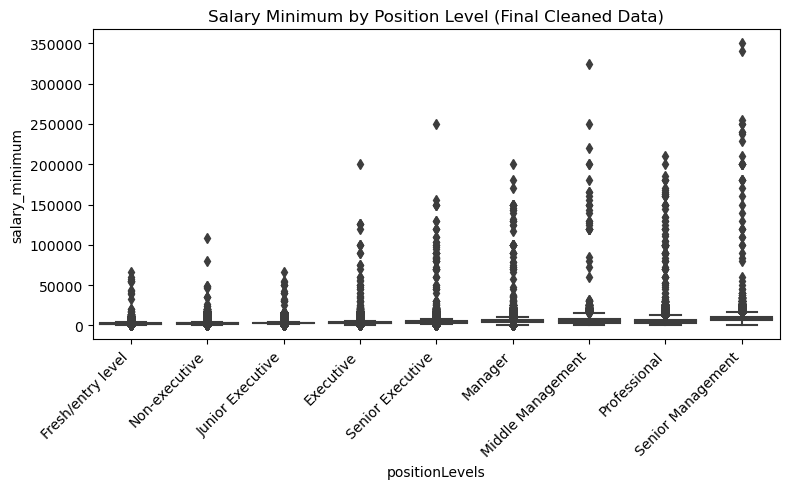

   employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies     positionLevels                                 postedCompany_name  salary_maximum  salary_minimum                                              title  average_salary  salary_median  salary_range_width salary_band  applications_per_vacancy  is_hard_to_fill  is_selective_hire                                      industry_list                  industry_primary  posting_year  posting_month  posting_quarter  posting_weekday  days_to_expiry  is_agency_post posting_month_year
0        Full Time          2023-12-06                      False   MCF-2023-0909376              2023-11-22                   2023-11-22                     0                                   1                          23                      10         

In [5]:
# analysis the high side of the salary_mminimum by positionLevels. clean the outliers if any

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the display order based on the median of 'salary_minimum'
order_min_salary = (
    df_cleaned_v2.groupby("positionLevels")["salary_minimum"]
    .median()
    .sort_values()
    .index
)

# Plot the box plot for salary_minimum
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_cleaned_v2,
    x="positionLevels",
    y="salary_minimum",
    order=order_min_salary,
)

plt.title("Salary Minimum by Position Level (Final Cleaned Data)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_3_min_per_level = df_cleaned_v2.groupby("positionLevels", as_index=False).apply(
    lambda x: x.nlargest(3, "salary_minimum")
).reset_index(drop=True)

print(top_3_min_per_level)

In [6]:
# check the low side of the salary_minimum and salary_maximum to see if there are any outliers or unusual values

salary_min_bottom10 = df_cleaned_v2['salary_minimum'].value_counts().sort_index().head(10)
salary_max_bottom10 = df_cleaned_v2['salary_maximum'].value_counts().sort_index().head(10)

print("Bottom 10 unique salary_minimum values (with counts):")
print(salary_min_bottom10)

print("\nBottom 10 unique salary_maximum values (with counts):")
print(salary_max_bottom10)

# Group by positionLevels, then show bottom 10 unique salary values within each group
result_min = (
    df_cleaned_v2.groupby('positionLevels')['salary_minimum']
    .value_counts()
    .sort_index()
    .groupby(level=0)
    .head(10)
)

result_max = (
    df_cleaned_v2.groupby('positionLevels')['salary_maximum']
    .value_counts()
    .sort_index()
    .groupby(level=0)
    .head(10)
)

print("Bottom 10 unique salary_minimum values per positionLevels:")
print(result_min)

print("\nBottom 10 unique salary_maximum values per positionLevels:")
print(result_max)

Bottom 10 unique salary_minimum values (with counts):
1     2534
2       21
3       13
4        7
5       11
6       16
7       33
8      194
9      360
10    1336
Name: salary_minimum, dtype: int64

Bottom 10 unique salary_maximum values (with counts):
1     1804
2      239
3        7
4        7
5        5
6        3
7        7
8       30
9      104
10     667
Name: salary_maximum, dtype: int64
Bottom 10 unique salary_minimum values per positionLevels:
positionLevels     salary_minimum
Executive          1                 632
                   2                   5
                   3                   2
                   4                   3
                   5                   1
                   6                   1
                   7                   2
                   8                   4
                   9                  13
                   10                 38
Fresh/entry level  1                 273
                   2                   2
                

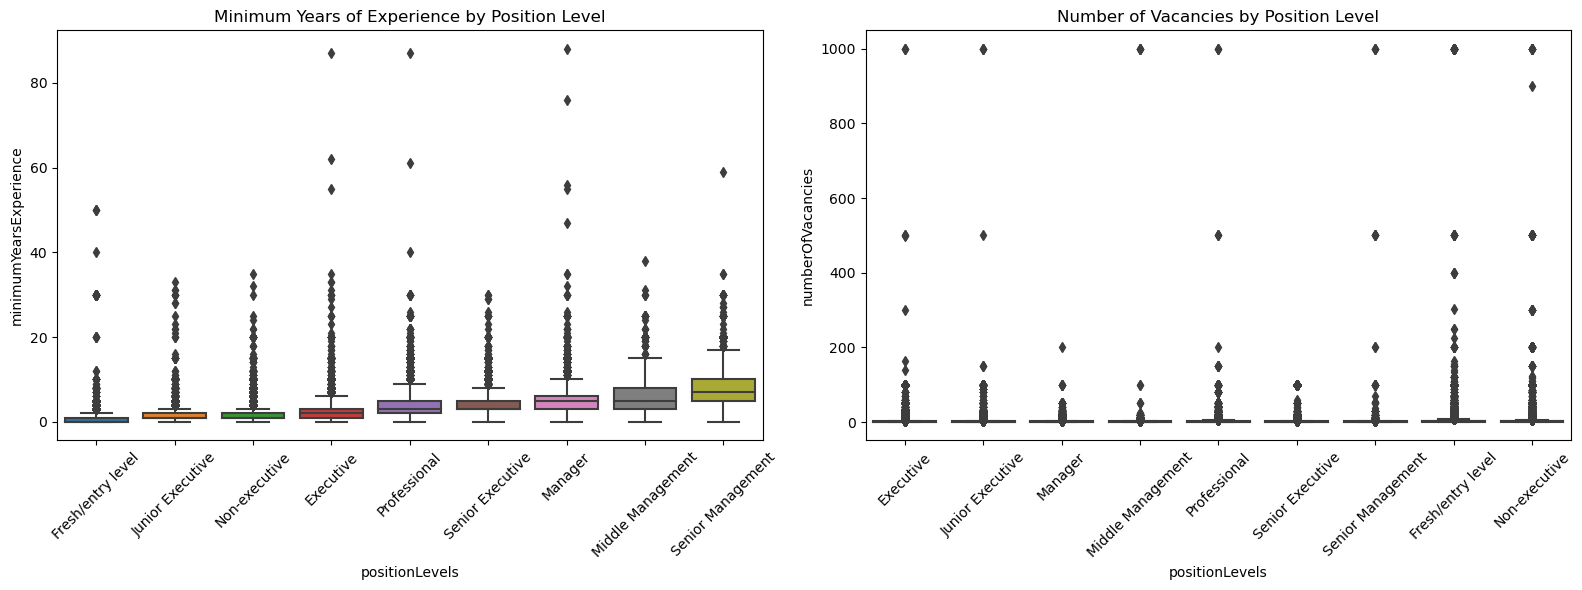

Top 15 unique numberOfVacancies values (with counts):
999    78
998     1
900     1
500    45
499     1
400     4
302     1
300    13
250     2
224     1
202     1
201     1
200    83
165     1
163     1
Name: numberOfVacancies, dtype: int64

Top 15 unique minimumYearsExperience values (with counts):
88    1
87    2
76    1
62    1
61    1
59    1
56    1
55    2
50    3
47    1
40    2
38    1
35    6
33    3
32    2
Name: minimumYearsExperience, dtype: int64


(1044567, 32)

In [7]:
# analyze the minimumYearsExperience and numberOfVacancies by positionLevels, and visualize the distributions using box plots
# drop rows w/ minimumYearsExperience >40

import matplotlib.pyplot as plt
import seaborn as sns

# Set up a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compute order of positionLevels by median value, ascending
order1 = (
    df_cleaned_v2.groupby("positionLevels")["minimumYearsExperience"]
    .median()
    .sort_values()
    .index
)

order2 = (
    df_cleaned_v2.groupby("positionLevels")["numberOfVacancies"]
    .median()
    .sort_values()
    .index
)

# Plot 1: Minimum Years of Experience by Position Level
sns.boxplot(
    data=df_cleaned_v2, x="positionLevels", y="minimumYearsExperience", order=order1, ax=axes[0]
)
axes[0].set_title("Minimum Years of Experience by Position Level")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Plot 2: Number of Vacancies by Position Level
sns.boxplot(
    data=df_cleaned_v2, x="positionLevels", y="numberOfVacancies", order=order2, ax=axes[1]
)
axes[1].set_title("Number of Vacancies by Position Level")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

vacancies_top15 = df_cleaned_v2['numberOfVacancies'].value_counts().sort_index(ascending=False).head(15)
experience_top15 = df_cleaned_v2['minimumYearsExperience'].value_counts().sort_index(ascending=False).head(15)

print("Top 15 unique numberOfVacancies values (with counts):")
print(vacancies_top15)

print("\nTop 15 unique minimumYearsExperience values (with counts):")
print(experience_top15)

df_cleaned_v2 = df_cleaned_v2[df_cleaned_v2['minimumYearsExperience'] <= 40]

df_cleaned_v2.shape

In [8]:
# re-check the db after cleaning
print(df_cleaned_v2.head())
print(df_cleaned_v2.shape)  # (rows, columns)

# 1. Structural Description: View column names, non-null counts, and data types
print("--- STRUCTURAL INFO ---")
df_cleaned_v2.info()

# 2. Statistical Description (Numeric columns): View count, mean, min, max, and percentiles
print("\n--- NUMERIC COLUMNS DESCRIBE ---")
print(df_cleaned_v2.describe())

# 3. Text/Categorical Description (String columns): View count, unique values, top item, and frequency
print("\n--- TEXT/CATEGORICAL COLUMNS DESCRIBE ---")
print(df_cleaned_v2.describe(include=['object']))

'''
#unique values and their exact counts for each column
for column in df_cleaned_v2.columns:
    print(f"=== Unique Values for Column: {column} ===")
    print(df_cleaned_v2[column].value_counts())
    print("\n" + "-"*40 + "\n")  # Visual separator
'''

# Count how many exact duplicate rows exist before dropping
duplicate_count = df_cleaned_v2.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Find and print the missing value counts for each column
print("=== Missing Values ===")
print(df_cleaned_v2.isnull().sum())

  employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies    positionLevels                postedCompany_name  salary_maximum  salary_minimum                                              title  average_salary  salary_median  salary_range_width salary_band  applications_per_vacancy  is_hard_to_fill  is_selective_hire                                      industry_list        industry_primary  posting_year  posting_month  posting_quarter  posting_weekday  days_to_expiry  is_agency_post posting_month_year
0       Permanent          2023-05-08                      False   MCF-2023-0252866              2023-04-08                   2023-03-30                     2                                   5                         151                       0                  1         Executive  

In [7]:
# save the cleaned DataFrame to a new CSV file
#df.to_csv('SGJobData_cleaned.csv', index=False)
#df.to_csv('../db/SGJobData_cleaned.csv.gz', index=False, compression='gzip')
df_cleaned_v2.to_csv('../db/SGJobData_cleaned.csv.gz', index=False, compression='gzip')